# 문제 정의

## 예측 목표


"""

목표: 초기 100 사이클 데이터만으로 배터리 전체 수명 예측

타겟: 사이클 수명 (80% SOH 도달 시점)

타겟 변환: log(cycle_life) 예측 후 역변환 (논문 방식)

평가 지표: MAPE(%), RMSE

"""


## 환경 설정 & 라이브러리

In [ ]:
import os, json, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from scipy import interpolate
from sklearn.linear_model import ElasticNetCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
import warnings
warnings.filterwarnings('ignore')

## 드라이브 마운트

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


## 경로 설정

In [ ]:
PROJECT_DIR = '/content/drive/MyDrive/battery_project'
DATA_DIR    = f'{PROJECT_DIR}/data'
CSV_PATH    = f'{PROJECT_DIR}/battery_cycles.csv'

print("✅ 라이브러리 로드 완료")
print(f"📂 JSON 파일 수: {len(glob.glob(f'{DATA_DIR}/*.json'))}")

✅ 라이브러리 로드 완료
📂 JSON 파일 수: 140


## 나눔고딕

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import os

font_path = '/content/drive/MyDrive/학술제/NanumGothic.ttf'

if not os.path.exists(font_path):
    print(f"Error: Font file not found at {font_path}")
else:
    !cp "{font_path}" /usr/local/share/fonts/
    !fc-cache -fv
    fm.fontManager.addfont("/usr/local/share/fonts/NanumGothic.ttf")
    plt.rc('font', family='NanumGothic')
    plt.rcParams['axes.unicode_minus'] = False
    print("NanumGothic font installed and configured for Matplotlib.")
    print(f"Current Matplotlib font family: {plt.rcParams['font.family']}")


/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 2 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 1 fonts, 0 dirs
/root/.local/share/fonts: skipping, no such directory
/root/.fonts: skipping, no such directory
/usr/share/fonts/truetype: skipping, looped directory detected
/usr/share/fonts/truetype/humor-sans: skipping, looped directory detected
/usr/share/fonts/truetype/liberation: skipping, looped directory detected
/var/cache/fontconfig: cleaning cache directory
/root/.cache/fontconfig: not cleaning non-existent cache directory
/root/.fontconfig: not cleaning non-existent cache directory
fc-cache: succeeded
NanumGothic font installed and configured for Matplotlib.
Current Matplotlib font family: ['NanumGothic']


#  EDA 코드

## CSV 로드 확인

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

PROJECT_DIR = '/content/drive/MyDrive/battery_project'
CSV_PATH    = f'{PROJECT_DIR}/battery_cycles.csv'

df = pd.read_csv(CSV_PATH)
print(f"형태: {df.shape}")
print(f"컬럼: {list(df.columns)}")
print(f"\n처음 5행:")
print(df.head())
print(f"\n기본 통계:")
print(df.describe().round(4))

형태: (114314, 8)
컬럼: ['barcode', 'protocol', 'cycle_index', 'discharge_capacity', 'charge_capacity', 'dc_internal_resistance', 'temperature_average', 'temperature_maximum']

처음 5행:
          barcode                protocol  cycle_index  discharge_capacity  \
0  el150800440551  20170630-4_4C_55per_6C            0            1.934572   
1  el150800440551  20170630-4_4C_55per_6C            1            1.045426   
2  el150800440551  20170630-4_4C_55per_6C            2            1.048037   
3  el150800440551  20170630-4_4C_55per_6C            3            1.048029   
4  el150800440551  20170630-4_4C_55per_6C            4            1.049100   

   charge_capacity  dc_internal_resistance  temperature_average  \
0         1.417352                0.029384            30.977694   
1         1.045648                0.017864            32.641014   
2         1.048442                0.017929            32.274544   
3         1.047885                0.018012            32.078480   
4         1.0491

##셀별 수명 집계

In [ ]:
# 셀별로 최대 사이클 수 = 수명
cell_life = df.groupby('barcode').agg(
    cycle_life   = ('cycle_index', 'max'),
    protocol     = ('protocol', 'first'),
    n_records    = ('cycle_index', 'count')
).reset_index()

print(f"총 셀 수: {len(cell_life)}개")
print(f"\n수명 통계:")
print(cell_life['cycle_life'].describe().round(0))
print(f"\n처음 5행:")
print(cell_life.head())

총 셀 수: 135개

수명 통계:
count     135.0
mean      821.0
std       361.0
min         0.0
25%       532.0
50%       788.0
75%      1006.0
max      2237.0
Name: cycle_life, dtype: float64

처음 5행:
          barcode  cycle_life                      protocol  n_records
0  EL150800453113         719    20170512-5_4C-60PER_3C.SDU        720
1  EL150800453773         617    20170512-7C-40PER_3_6C.SDU        618
2  EL150800460433         890    20170512-6C-30PER_3_6C.SDU        891
3  EL150800460436         757      20170512-6C-60PER_3C.SDU        758
4  EL150800460468        1054  20170512-5_4C-40PER_3_6C.SDU       1055


## 수명 분포 시각화

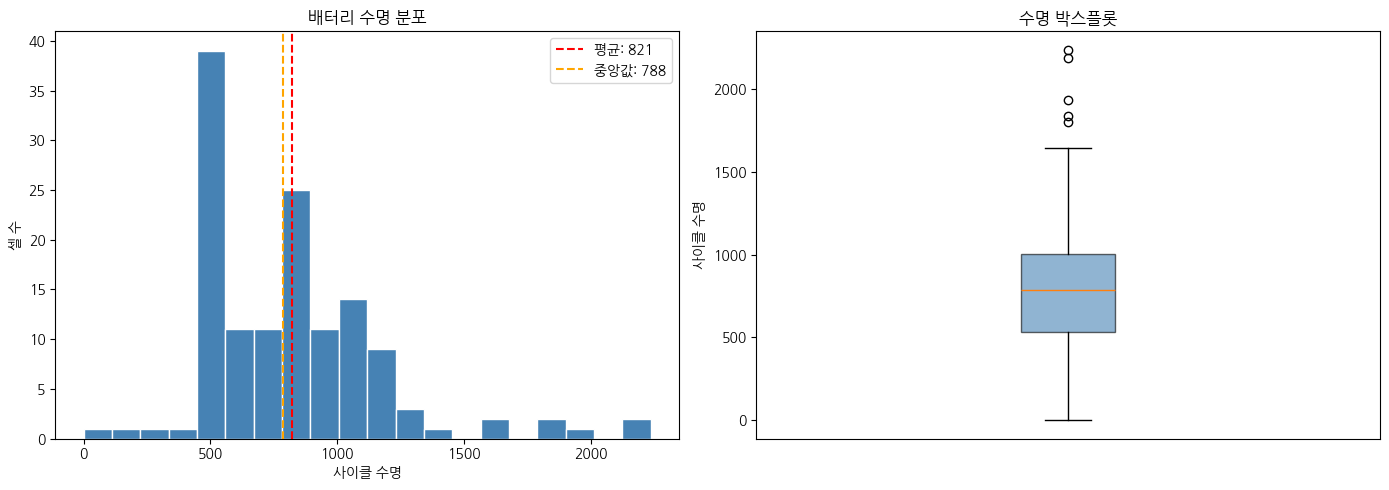


수명 범위: 0 ~ 2237 사이클


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 히스토그램
axes[0].hist(cell_life['cycle_life'], bins=20, color='steelblue', edgecolor='white')
axes[0].axvline(cell_life['cycle_life'].mean(), color='red', linestyle='--',
                label=f"평균: {cell_life['cycle_life'].mean():.0f}")
axes[0].axvline(cell_life['cycle_life'].median(), color='orange', linestyle='--',
                label=f"중앙값: {cell_life['cycle_life'].median():.0f}")
axes[0].set_title('배터리 수명 분포')
axes[0].set_xlabel('사이클 수명')
axes[0].set_ylabel('셀 수')
axes[0].legend()

# 박스플롯
axes[1].boxplot(cell_life['cycle_life'], vert=True, patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.6))
axes[1].set_title('수명 박스플롯')
axes[1].set_ylabel('사이클 수명')
axes[1].set_xticks([])

plt.tight_layout()
plt.savefig(f'{PROJECT_DIR}/eda_01_cycle_life_dist.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n수명 범위: {cell_life['cycle_life'].min()} ~ {cell_life['cycle_life'].max()} 사이클")

## 용량 감소 곡선 (사이클별 discharge_capacity)

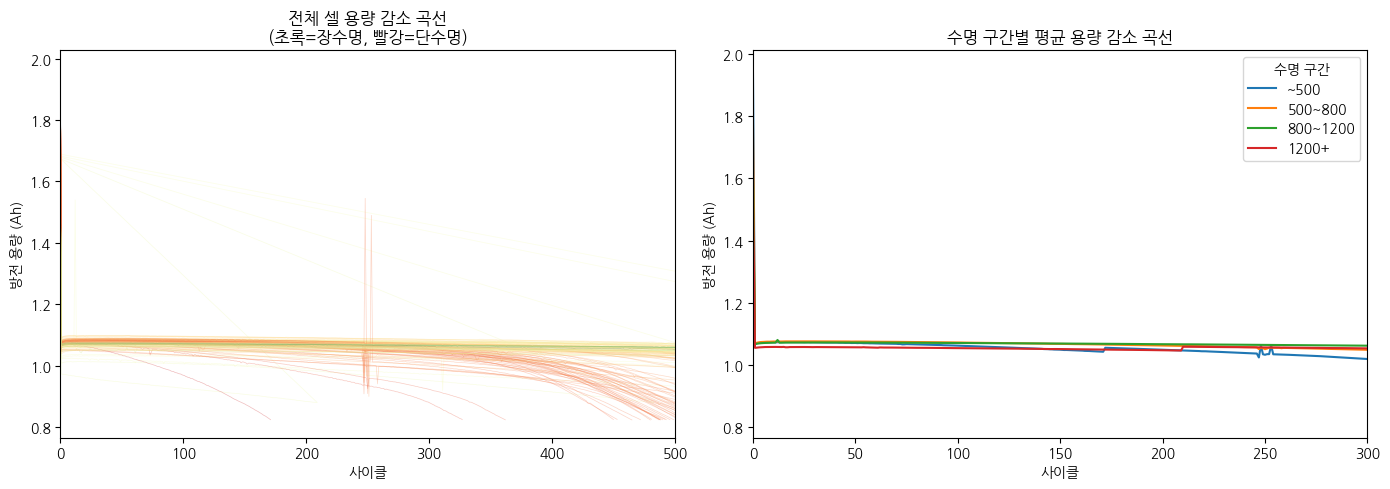

In [ ]:
# 셀별 용량 감소 곡선
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 왼쪽: 전체 셀 용량 감소 곡선
for barcode, group in df.groupby('barcode'):
    cycle_life = group['cycle_index'].max()
    color = plt.cm.RdYlGn(cycle_life / cell_life['cycle_life'].max())
    axes[0].plot(group['cycle_index'], group['discharge_capacity'],
                 alpha=0.3, linewidth=0.5, color=color)

axes[0].set_title('전체 셀 용량 감소 곡선\n(초록=장수명, 빨강=단수명)')
axes[0].set_xlabel('사이클')
axes[0].set_ylabel('방전 용량 (Ah)')
axes[0].set_xlim(0, 500)  # 초기 500 사이클

# 오른쪽: 수명 구간별 평균 곡선
bins = [0, 500, 800, 1200, 3000]
labels = ['~500', '500~800', '800~1200', '1200+']
cell_life['life_group'] = pd.cut(cell_life['cycle_life'], bins=bins, labels=labels)

df2 = df.merge(cell_life[['barcode', 'life_group']], on='barcode')
for group_name, group_data in df2.groupby('life_group', observed=True):
    mean_cap = group_data.groupby('cycle_index')['discharge_capacity'].mean()
    axes[1].plot(mean_cap.index, mean_cap.values, label=group_name, linewidth=1.5)

axes[1].set_title('수명 구간별 평균 용량 감소 곡선')
axes[1].set_xlabel('사이클')
axes[1].set_ylabel('방전 용량 (Ah)')
axes[1].set_xlim(0, 300)
axes[1].legend(title='수명 구간')

plt.tight_layout()
plt.savefig(f'{PROJECT_DIR}/eda_02_capacity_fade.png', dpi=150, bbox_inches='tight')
plt.show()

## json 구조 확인

In [ ]:
import numpy as np

# cycle_index로 사이클 구분
cycle_idx = np.array(cycles['cycle_index'])
voltage    = np.array(cycles['voltage'])
dis_cap    = np.array(cycles['discharge_capacity'])
step_type  = np.array(cycles['step_type'])

print(f"전체 데이터 포인트: {len(cycle_idx)}")
print(f"고유 사이클 수: {len(np.unique(cycle_idx))}")
print(f"step_type 종류: {np.unique(step_type)}")

# 사이클 10, 방전 구간만 추출
mask10 = (cycle_idx == 10) & (step_type == 'discharge')
mask100 = (cycle_idx == 100) & (step_type == 'discharge')

print(f"\n사이클 10 포인트 수: {mask10.sum()}")
print(f"사이클 100 포인트 수: {mask100.sum()}")

print(f"\n사이클 10 전압 범위: {voltage[mask10].min():.3f} ~ {voltage[mask10].max():.3f}")
print(f"사이클 100 전압 범위: {voltage[mask100].min():.3f} ~ {voltage[mask100].max():.3f}")

전체 데이터 포인트: 1658000
고유 사이클 수: 829
step_type 종류: ['charge' 'discharge']

사이클 10 포인트 수: 1000
사이클 100 포인트 수: 1000

사이클 10 전압 범위: 2.800 ~ 3.500
사이클 100 전압 범위: 2.800 ~ 3.500


## ΔQ 계산

✅ ΔQ 계산 성공
분산: 0.000135
최솟값: -0.026908


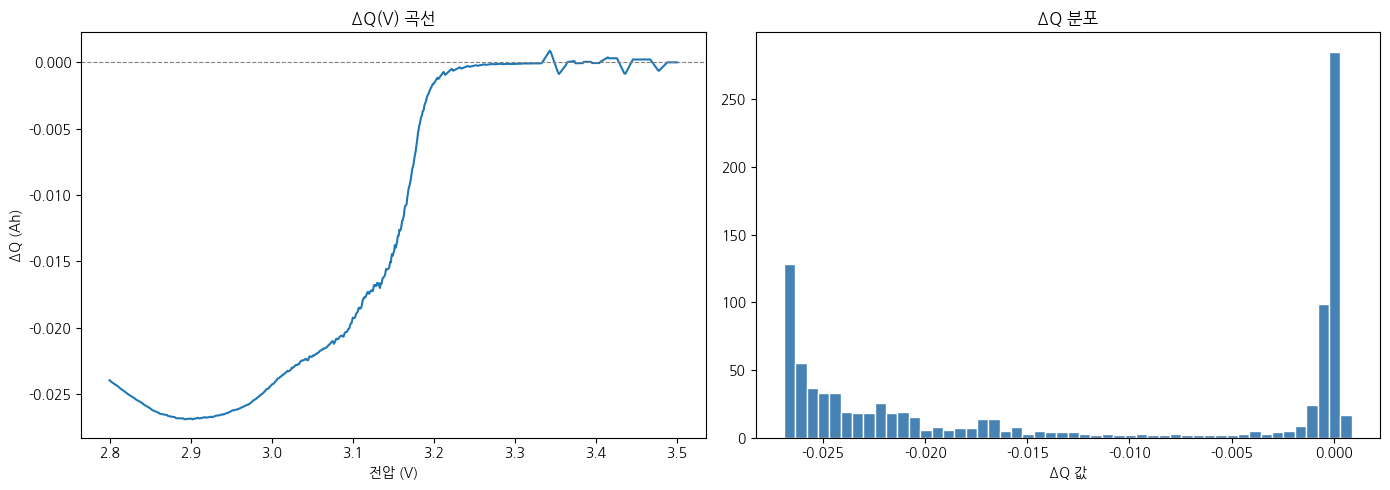

In [ ]:
from scipy import interpolate

def compute_deltaQ_from_cell(cycles, cycle_a=10, cycle_b=100):
    cycle_idx = np.array(cycles['cycle_index'])
    voltage   = np.array(cycles['voltage'])
    dis_cap   = np.array(cycles['discharge_capacity'])
    step_type = np.array(cycles['step_type'])

    mask_a = (cycle_idx == cycle_a) & (step_type == 'discharge')
    mask_b = (cycle_idx == cycle_b) & (step_type == 'discharge')

    if mask_a.sum() == 0 or mask_b.sum() == 0:
        return None

    V_a, Q_a = voltage[mask_a], dis_cap[mask_a]
    V_b, Q_b = voltage[mask_b], dis_cap[mask_b]

    # 공통 전압 구간에서 보간
    V_min = max(V_a.min(), V_b.min())
    V_max = min(V_a.max(), V_b.max())
    V_grid = np.linspace(V_min, V_max, 1000)

    Q_a_interp = np.interp(V_grid, np.sort(V_a), Q_a[np.argsort(V_a)])
    Q_b_interp = np.interp(V_grid, np.sort(V_b), Q_b[np.argsort(V_b)])

    delta_Q = Q_b_interp - Q_a_interp
    return delta_Q

# 테스트
dq = compute_deltaQ_from_cell(cycles)
print(f"✅ ΔQ 계산 성공")
print(f"분산: {np.var(dq):.6f}")
print(f"최솟값: {np.min(dq):.6f}")

# 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(np.linspace(2.8, 3.5, 1000), dq)
axes[0].axhline(0, color='gray', linestyle='--', linewidth=0.8)
axes[0].set_xlabel('전압 (V)')
axes[0].set_ylabel('ΔQ (Ah)')
axes[0].set_title('ΔQ(V) 곡선')

axes[1].hist(dq, bins=50, color='steelblue', edgecolor='white')
axes[1].set_xlabel('ΔQ 값')
axes[1].set_title('ΔQ 분포')

plt.tight_layout()
plt.show()

## 전체 140개 셀 feature 추출

In [ ]:
from tqdm.notebook import tqdm

json_files = sorted(glob.glob(f'{DATA_DIR}/*.json'))
feat_rows = []

for path in tqdm(json_files, desc="Feature 추출 중"):
    with open(path, 'r') as f:
        data = json.load(f)

    barcode  = data.get('barcode', '')
    cycles   = data['cycles_interpolated']
    summary  = data['summary']

    # 수명 계산
    cycle_life = max(summary['cycle_index'])

    # ΔQ 계산
    dq = compute_deltaQ_from_cell(cycles)
    if dq is None:
        continue

    # 초기 용량 (사이클 2)
    cycle_idx = np.array(cycles['cycle_index'])
    dis_cap   = np.array(cycles['discharge_capacity'])
    step_type = np.array(cycles['step_type'])

    mask2 = (cycle_idx == 2) & (step_type == 'discharge')
    Q2 = dis_cap[mask2].max() if mask2.sum() > 0 else np.nan

    # 내부저항 차이 (사이클 2 vs 100)
    ir = np.array(cycles['internal_resistance'])
    ir2   = ir[cycle_idx == 2].mean()   if (cycle_idx == 2).sum() > 0 else np.nan
    ir100 = ir[cycle_idx == 100].mean() if (cycle_idx == 100).sum() > 0 else np.nan

    feat_rows.append({
        'barcode':      barcode,
        'cycle_life':   cycle_life,
        'deltaQ_var':   np.var(dq),
        'deltaQ_min':   np.min(dq),
        'deltaQ_mean':  np.mean(dq),
        'deltaQ_skew':  float(pd.Series(dq).skew()),
        'Q2':           Q2,
        'delta_IR':     ir100 - ir2,
    })

cell_feat = pd.DataFrame(feat_rows)
cell_feat.to_csv(f'{PROJECT_DIR}/cell_feat.csv', index=False)

print(f"✅ 완료: {len(cell_feat)}개 셀")
print(cell_feat.describe().round(4))

Feature 추출 중:   0%|          | 0/140 [00:00<?, ?it/s]

✅ 완료: 139개 셀
       cycle_life  deltaQ_var  deltaQ_min  deltaQ_mean  deltaQ_skew        Q2  \
count    139.0000    139.0000    139.0000     139.0000     139.0000  139.0000   
mean     821.3957      0.0004     -0.0391      -0.0180      -0.0038    0.9956   
std      355.0993      0.0005      0.0208       0.0106       0.2023    0.0199   
min      171.0000      0.0000     -0.1381      -0.0659      -1.0293    0.8653   
25%      531.5000      0.0001     -0.0512      -0.0243      -0.0622    0.9935   
50%      788.0000      0.0002     -0.0369      -0.0169       0.0424    0.9989   
75%     1005.5000      0.0005     -0.0255      -0.0114       0.0908    1.0052   
max     2237.0000      0.0036     -0.0049       0.0044       0.9515    1.0266   

       delta_IR  
count       0.0  
mean        NaN  
std         NaN  
min         NaN  
25%         NaN  
50%         NaN  
75%         NaN  
max         NaN  


# 사용 모델 : Elastic Net (선형 회귀)

논문 결과 : 9.1%

사용 이유

데이터가 124개밖에 없음

→ 딥러닝 쓰면 과적합

→ 단순한 선형 모델이 오히려 더 잘 작동

# 모델링 : 시도 1

사용 셀 수: 139
Train: 42, Val: 42, Test: 55

최적 lambda: 0.0175
최적 l1_ratio: 0.1

 feature 중요도:
  deltaQ_var: 0.1360
  deltaQ_min: 0.1564
  deltaQ_mean: 0.2771
  deltaQ_skew: -0.0723
  Q2: 0.1119

=== Test 성능 ===
MAPE: 13.86%
RMSE: 99.5 사이클


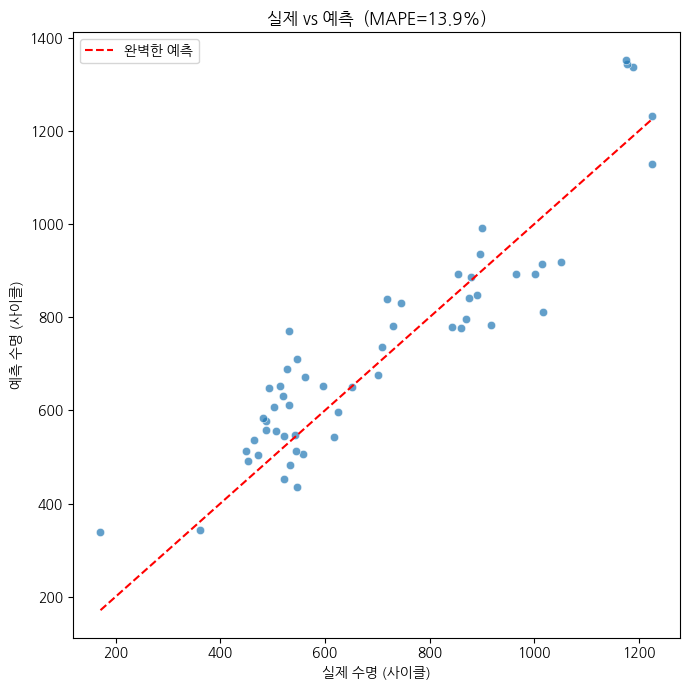

In [ ]:
from sklearn.linear_model import ElasticNetCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
import numpy as np

# delta_IR 제외 (NaN)
feat_cols = ['deltaQ_var', 'deltaQ_min', 'deltaQ_mean', 'deltaQ_skew', 'Q2']

cell_feat = cell_feat.dropna(subset=feat_cols)
print(f"사용 셀 수: {len(cell_feat)}")

# 논문 방식 Train/Val/Test 분할 (순서대로)
n = len(cell_feat)
n_train = round(n * 0.3)
n_val   = round(n * 0.3)

train = cell_feat.iloc[:n_train]
val   = cell_feat.iloc[n_train:n_train+n_val]
test  = cell_feat.iloc[n_train+n_val:]

print(f"Train: {len(train)}, Val: {len(val)}, Test: {len(test)}")

# X, Y 분리
X_train = train[feat_cols].values
X_val   = val[feat_cols].values
X_test  = test[feat_cols].values

y_train = np.log(train['cycle_life'].values)
y_val   = np.log(val['cycle_life'].values)
y_test  = np.log(test['cycle_life'].values)

# 정규화
scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)

# Elastic Net (train+val 합쳐서 CV)
X_trainval = np.vstack([X_train, X_val])
y_trainval = np.concatenate([y_train, y_val])

model = ElasticNetCV(
    l1_ratio  = [0.1, 0.5, 0.7, 0.9, 1.0],
    cv        = 5,
    max_iter  = 10000,
    random_state = 42
)
model.fit(X_trainval, y_trainval)

print(f"\n최적 lambda: {model.alpha_:.4f}")
print(f"최적 l1_ratio: {model.l1_ratio_:.1f}")
print(f"\n feature 중요도:")
for col, coef in zip(feat_cols, model.coef_):
    print(f"  {col}: {coef:.4f}")

# 예측
y_pred_log = model.predict(X_test)
y_pred     = np.exp(y_pred_log)
y_true     = np.exp(y_test)

# 평가
mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
rmse = np.sqrt(mean_squared_error(y_true, y_pred))

print(f"\n=== Test 성능 ===")
print(f"MAPE: {mape:.2f}%")
print(f"RMSE: {rmse:.1f} 사이클")

# 시각화
fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(y_true, y_pred, alpha=0.7, edgecolors='white', linewidth=0.5)
ax.plot([y_true.min(), y_true.max()],
        [y_true.min(), y_true.max()],
        'r--', linewidth=1.5, label='완벽한 예측')
ax.set_xlabel('실제 수명 (사이클)')
ax.set_ylabel('예측 수명 (사이클)')
ax.set_title(f'실제 vs 예측  (MAPE={mape:.1f}%)')
ax.legend()
plt.tight_layout()
plt.savefig(f'{PROJECT_DIR}/model_01_prediction.png', dpi=150, bbox_inches='tight')
plt.show()

# 논문과 차이 발생 이유

## delta_IR 빠짐 (NaN이라 제외)

In [ ]:
# delta_IR NaN 원인 확인
path = sorted(glob.glob(f'{DATA_DIR}/*.json'))[5]

with open(path, 'r') as f:
    data = json.load(f)

cycles   = data['cycles_interpolated']
cycle_idx = np.array(cycles['cycle_index'])
ir        = np.array(cycles['internal_resistance'])
step_type = np.array(cycles['step_type'])

print(f"internal_resistance 샘플: {ir[:10]}")
print(f"고유값 수: {len(np.unique(ir))}")
print(f"NaN 수: {np.isnan(ir).sum()}")
print(f"0인 값 수: {(ir == 0).sum()}")

# 사이클 2, 100 마스크
mask2   = cycle_idx == 2
mask100 = cycle_idx == 100

print(f"\n사이클 2 IR 값: {ir[mask2][:5]}")
print(f"사이클 100 IR 값: {ir[mask100][:5]}")
print(f"\nsstep_type 사이클2: {np.unique(step_type[mask2])}")

internal_resistance 샘플: [0.0155116 0.0155116 0.0155116 0.0155116 0.0155116 0.0155116 0.0155116
 0.0155116 0.0155116 0.0155116]
고유값 수: 826
NaN 수: 342784
0인 값 수: 0

사이클 2 IR 값: [0.01543813 0.01543813 0.01543813 0.01543813 0.01543813]
사이클 100 IR 값: [0.01526545 0.01526545 0.01526545 0.01526545 0.01526545]

sstep_type 사이클2: ['charge' 'discharge']


NaN이 342,784개나 있어서 사이클 2나 100이 NaN인 셀들이 존재

평균 내면 NaN

해결책 :NaN 제외하고 평균 내기

근데 효과 미미할 것으로 예상

In [ ]:
from tqdm.notebook import tqdm

json_files = sorted(glob.glob(f'{DATA_DIR}/*.json'))
feat_rows = []

for path in tqdm(json_files, desc="Feature 추출 중"):
    with open(path, 'r') as f:
        data = json.load(f)

    barcode  = data.get('barcode', '')
    cycles   = data['cycles_interpolated']
    summary  = data['summary']

    cycle_life = max(summary['cycle_index'])

    dq = compute_deltaQ_from_cell(cycles)
    if dq is None:
        continue

    cycle_idx = np.array(cycles['cycle_index'])
    dis_cap   = np.array(cycles['discharge_capacity'])
    step_type = np.array(cycles['step_type'])
    ir        = np.array(cycles['internal_resistance'])

    # 초기 용량 (사이클 2)
    mask2 = (cycle_idx == 2) & (step_type == 'discharge')
    Q2 = dis_cap[mask2].max() if mask2.sum() > 0 else np.nan

    # 내부저항 - NaN 제외하고 평균
    ir2_vals   = ir[(cycle_idx == 2) & ~np.isnan(ir)]
    ir100_vals = ir[(cycle_idx == 100) & ~np.isnan(ir)]

    ir2   = ir2_vals.mean()   if len(ir2_vals) > 0   else np.nan
    ir100 = ir100_vals.mean() if len(ir100_vals) > 0 else np.nan
    delta_IR = ir100 - ir2 if not np.isnan(ir2) and not np.isnan(ir100) else np.nan

    feat_rows.append({
        'barcode':      barcode,
        'cycle_life':   cycle_life,
        'deltaQ_var':   np.var(dq),
        'deltaQ_min':   np.min(dq),
        'deltaQ_mean':  np.mean(dq),
        'deltaQ_skew':  float(pd.Series(dq).skew()),
        'Q2':           Q2,
        'delta_IR':     delta_IR,
    })

cell_feat = pd.DataFrame(feat_rows)
cell_feat.to_csv(f'{PROJECT_DIR}/cell_feat.csv', index=False)

print(f"✅ 완료: {len(cell_feat)}개 셀")
print(f"delta_IR NaN 수: {cell_feat['delta_IR'].isna().sum()}")
print(cell_feat[['cycle_life', 'deltaQ_var', 'delta_IR']].describe().round(6))

Feature 추출 중:   0%|          | 0/140 [00:00<?, ?it/s]

KeyboardInterrupt: 

우선 시간 오래 걸리니 더 영향도 높은 요인 탐색

## slope feature(초기 100사이클 동안 용량이 얼마나 빠르게 줄어드는가) 추가

빨간 선들 (단수명): 기울기 가파름 → slope 큼

초록 선들 (장수명): 기울기 완만함 → slope 작음

In [ ]:
from tqdm.notebook import tqdm

json_files = sorted(glob.glob(f'{DATA_DIR}/*.json'))
feat_rows = []

for path in tqdm(json_files, desc="Feature 추출 중"):
    with open(path, 'r') as f:
        data = json.load(f)

    barcode  = data.get('barcode', '')
    cycles   = data['cycles_interpolated']
    summary  = data['summary']

    cycle_life = max(summary['cycle_index'])

    dq = compute_deltaQ_from_cell(cycles)
    if dq is None:
        continue

    cycle_idx = np.array(cycles['cycle_index'])
    dis_cap   = np.array(cycles['discharge_capacity'])
    step_type = np.array(cycles['step_type'])
    ir        = np.array(cycles['internal_resistance'])

    # 초기 용량 (사이클 2)
    mask2 = (cycle_idx == 2) & (step_type == 'discharge')
    Q2 = dis_cap[mask2].max() if mask2.sum() > 0 else np.nan

    # slope: 사이클 2~100 방전 용량 감소 기울기
    slope_cycles, slope_caps = [], []
    for c in range(2, 101):
        mask = (cycle_idx == c) & (step_type == 'discharge')
        if mask.sum() > 0:
            slope_cycles.append(c)
            slope_caps.append(dis_cap[mask].max())

    if len(slope_cycles) >= 2:
        slope = np.polyfit(slope_cycles, slope_caps, 1)[0]
    else:
        slope = np.nan

    # 내부저항 - NaN 제외
    ir2_vals   = ir[(cycle_idx == 2)   & ~np.isnan(ir)]
    ir100_vals = ir[(cycle_idx == 100) & ~np.isnan(ir)]
    ir2        = ir2_vals.mean()   if len(ir2_vals)   > 0 else np.nan
    ir100      = ir100_vals.mean() if len(ir100_vals) > 0 else np.nan
    delta_IR   = ir100 - ir2 if not np.isnan(ir2) and not np.isnan(ir100) else np.nan

    feat_rows.append({
        'barcode':    barcode,
        'cycle_life': cycle_life,
        'deltaQ_var':  np.var(dq),
        'deltaQ_min':  np.min(dq),
        'deltaQ_mean': np.mean(dq),
        'deltaQ_skew': float(pd.Series(dq).skew()),
        'Q2':          Q2,
        'slope':       slope,
        'delta_IR':    delta_IR,
    })

cell_feat = pd.DataFrame(feat_rows)
cell_feat.to_csv(f'{PROJECT_DIR}/cell_feat.csv', index=False)

print(f"✅ 완료: {len(cell_feat)}개 셀")
print(f"NaN 수:\n{cell_feat.isna().sum()}")
print(cell_feat.describe().round(6))

Feature 추출 중:   0%|          | 0/140 [00:00<?, ?it/s]

✅ 완료: 139개 셀
NaN 수:
barcode        0
cycle_life     0
deltaQ_var     0
deltaQ_min     0
deltaQ_mean    0
deltaQ_skew    0
Q2             0
slope          1
delta_IR       0
dtype: int64
        cycle_life  deltaQ_var  deltaQ_min  deltaQ_mean  deltaQ_skew  \
count   139.000000  139.000000  139.000000   139.000000   139.000000   
mean    821.395683    0.000374   -0.039110    -0.018044    -0.003837   
std     355.099264    0.000489    0.020784     0.010575     0.202345   
min     171.000000    0.000009   -0.138120    -0.065886    -1.029314   
25%     531.500000    0.000121   -0.051238    -0.024291    -0.062197   
50%     788.000000    0.000233   -0.036912    -0.016912     0.042427   
75%    1005.500000    0.000504   -0.025488    -0.011404     0.090814   
max    2237.000000    0.003605   -0.004863     0.004428     0.951503   

               Q2       slope    delta_IR  
count  139.000000  138.000000  139.000000  
mean     0.995610   -0.000366   -0.000146  
std      0.019901    0.000198    

## 모델링 재시도

사용 셀 수: 138
Train: 41, Val: 41, Test: 56

=== Elastic Net 성능 ===
MAPE: 13.18%  (논문: 9.1%)
RMSE: 97.7 사이클
최적 lambda: 0.0158
최적 l1_ratio: 0.1

feature 계수:
  deltaQ_var: 0.2528
  deltaQ_mean: 0.2129
  slope: 0.2056
  Q2: 0.1483
  deltaQ_min: 0.1352
  deltaQ_skew: -0.0561
  delta_IR: 0.0034


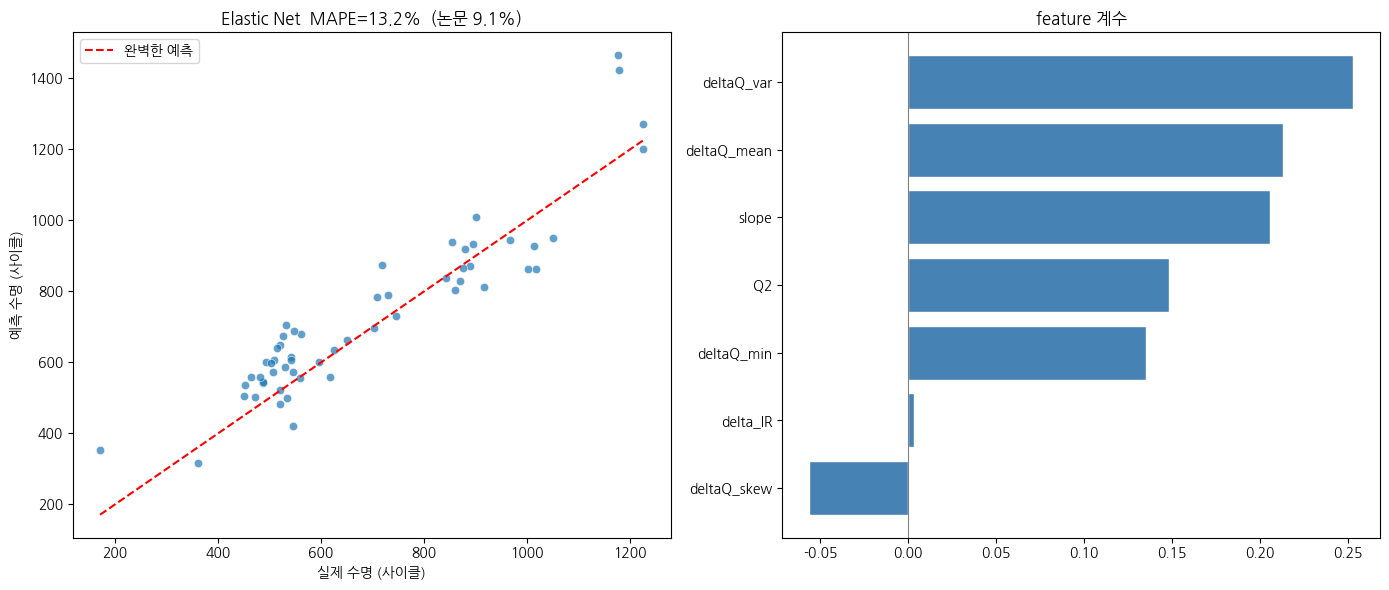

In [ ]:
from sklearn.linear_model import ElasticNetCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
import numpy as np

feat_cols = ['deltaQ_var', 'deltaQ_min', 'deltaQ_mean', 'deltaQ_skew', 'Q2', 'slope', 'delta_IR']

# slope NaN 1개 제거
cell_feat_clean = cell_feat.dropna(subset=feat_cols)
print(f"사용 셀 수: {len(cell_feat_clean)}")

# 분할
n       = len(cell_feat_clean)
n_train = round(n * 0.3)
n_val   = round(n * 0.3)

train = cell_feat_clean.iloc[:n_train]
val   = cell_feat_clean.iloc[n_train:n_train+n_val]
test  = cell_feat_clean.iloc[n_train+n_val:]

print(f"Train: {len(train)}, Val: {len(val)}, Test: {len(test)}")

X_train = train[feat_cols].values
X_val   = val[feat_cols].values
X_test  = test[feat_cols].values

y_train = np.log(train['cycle_life'].values)
y_val   = np.log(val['cycle_life'].values)
y_test  = np.log(test['cycle_life'].values)

X_trainval = np.vstack([X_train, X_val])
y_trainval = np.concatenate([y_train, y_val])

# 정규화
scaler    = StandardScaler()
X_tr_sc   = scaler.fit_transform(X_trainval)
X_test_sc = scaler.transform(X_test)

# Elastic Net
en = ElasticNetCV(
    l1_ratio     = [0.1, 0.5, 0.7, 0.9, 1.0],
    cv           = 5,
    max_iter     = 10000,
    random_state = 42
)
en.fit(X_tr_sc, y_trainval)

y_pred = np.exp(en.predict(X_test_sc))
y_true = np.exp(y_test)

mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
rmse = np.sqrt(mean_squared_error(y_true, y_pred))

print(f"\n=== Elastic Net 성능 ===")
print(f"MAPE: {mape:.2f}%  (논문: 9.1%)")
print(f"RMSE: {rmse:.1f} 사이클")
print(f"최적 lambda: {en.alpha_:.4f}")
print(f"최적 l1_ratio: {en.l1_ratio_:.1f}")

print(f"\nfeature 계수:")
for col, coef in sorted(zip(feat_cols, en.coef_),
                         key=lambda x: abs(x[1]), reverse=True):
    print(f"  {col}: {coef:.4f}")

# 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].scatter(y_true, y_pred, alpha=0.7, edgecolors='white', linewidth=0.5)
axes[0].plot([y_true.min(), y_true.max()],
             [y_true.min(), y_true.max()],
             'r--', linewidth=1.5, label='완벽한 예측')
axes[0].set_xlabel('실제 수명 (사이클)')
axes[0].set_ylabel('예측 수명 (사이클)')
axes[0].set_title(f'Elastic Net  MAPE={mape:.1f}%  (논문 9.1%)')
axes[0].legend()

coef_df = pd.Series(en.coef_, index=feat_cols).sort_values()
axes[1].barh(coef_df.index, coef_df.values, color='steelblue', edgecolor='white')
axes[1].axvline(0, color='gray', linewidth=0.8)
axes[1].set_title('feature 계수')

plt.tight_layout()
plt.savefig(f'{PROJECT_DIR}/model_elastic_net.png', dpi=150, bbox_inches='tight')
plt.show()

# 사용 모델 : Random Forest

논문 결과 : 12.0%

사용 셀 수: 138, feature: ['deltaQ_var', 'deltaQ_min', 'deltaQ_mean', 'deltaQ_skew', 'Q2', 'slope', 'delta_IR']

=== Random Forest 성능 ===
MAPE: 13.87%
RMSE: 156.1 사이클

feature 중요도:
  deltaQ_min: 0.3200
  slope: 0.2602
  deltaQ_var: 0.1773
  deltaQ_mean: 0.1216
  Q2: 0.0517
  delta_IR: 0.0449
  deltaQ_skew: 0.0243


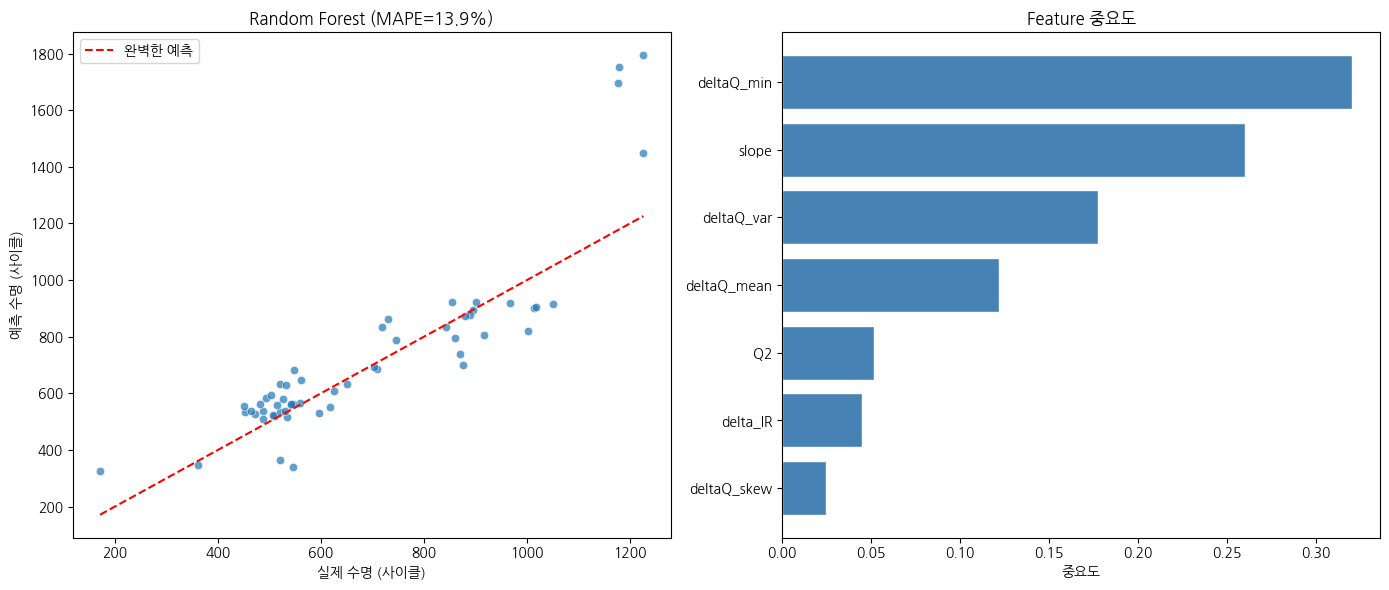

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
import numpy as np

feat_cols = ['deltaQ_var', 'deltaQ_min', 'deltaQ_mean', 'deltaQ_skew', 'Q2', 'slope', 'delta_IR']

# NaN 제거
cell_feat_rf = cell_feat.dropna(subset=[c for c in feat_cols if c in cell_feat.columns])
feat_cols_rf = [c for c in feat_cols if c in cell_feat_rf.columns]
print(f"사용 셀 수: {len(cell_feat_rf)}, feature: {feat_cols_rf}")

# 분할
n = len(cell_feat_rf)
n_train = round(n * 0.3)
n_val   = round(n * 0.3)

train = cell_feat_rf.iloc[:n_train]
val   = cell_feat_rf.iloc[n_train:n_train+n_val]
test  = cell_feat_rf.iloc[n_train+n_val:]

X_train = train[feat_cols_rf].values
X_val   = val[feat_cols_rf].values
X_test  = test[feat_cols_rf].values

y_train = np.log(train['cycle_life'].values)
y_val   = np.log(val['cycle_life'].values)
y_test  = np.log(test['cycle_life'].values)

# Train + Val 합쳐서 학습
X_trainval = np.vstack([X_train, X_val])
y_trainval = np.concatenate([y_train, y_val])

# Random Forest
rf = RandomForestRegressor(
    n_estimators = 100,
    max_depth    = None,
    random_state = 42
)
rf.fit(X_trainval, y_trainval)

# 예측
y_pred_log = rf.predict(X_test)
y_pred     = np.exp(y_pred_log)
y_true     = np.exp(y_test)

# 평가
mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
rmse = np.sqrt(mean_squared_error(y_true, y_pred))

print(f"\n=== Random Forest 성능 ===")
print(f"MAPE: {mape:.2f}%")
print(f"RMSE: {rmse:.1f} 사이클")

# feature 중요도
print(f"\nfeature 중요도:")
for col, imp in sorted(zip(feat_cols_rf, rf.feature_importances_),
                        key=lambda x: x[1], reverse=True):
    print(f"  {col}: {imp:.4f}")

# 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# scatter plot
axes[0].scatter(y_true, y_pred, alpha=0.7, edgecolors='white', linewidth=0.5)
axes[0].plot([y_true.min(), y_true.max()],
             [y_true.min(), y_true.max()],
             'r--', linewidth=1.5, label='완벽한 예측')
axes[0].set_xlabel('실제 수명 (사이클)')
axes[0].set_ylabel('예측 수명 (사이클)')
axes[0].set_title(f'Random Forest (MAPE={mape:.1f}%)')
axes[0].legend()

# feature 중요도 막대그래프
importances = sorted(zip(feat_cols_rf, rf.feature_importances_),
                     key=lambda x: x[1], reverse=True)
axes[1].barh([x[0] for x in importances],
             [x[1] for x in importances],
             color='steelblue', edgecolor='white')
axes[1].set_xlabel('중요도')
axes[1].set_title('Feature 중요도')
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig(f'{PROJECT_DIR}/model_02_random_forest.png', dpi=150, bbox_inches='tight')
plt.show()